In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

In [2]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                
                fig,ax = plt.subplots(figsize = (3.5,2.5))
            
                sns.swarmplot(x=cat_name, y =column, data= param_df, palette = palette, order = order, alpha = 0.7, size = 4)
                sns.boxplot(x=cat_name, y =column, data= param_df, palette = palette, order = order, boxprops=dict(alpha=0.5), width = 0.5)
                sns.despine()
                plt.title(column, pad = 20)
                plt.xticks(rotation = 90)
                plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# epnys analysis

In [3]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

include_gal = True

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

cat = df.Behaviour_6hFD.unique()

if include_gal:
       gal = df[(df.Gal_positive == 'yes') & (df.Behaviour_6hFD == 'Pre')]
       no_gal = df[(df.Gal_positive == 'no') & (df.Behaviour_6hFD == 'Pre')]
       ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD != 'Pre']])
       sample_num= int(no_gal.shape[0]/4)
       ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 62)]).reset_index(drop = True)

else:
       ephys = df[df.Gal_positive == 'Unknown']
# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [4]:
behav = pd.read_csv('ephys_behav.csv')
ephys_behav = pd.merge(ephys, behav, on  = 'ID_mouse')
ephys_behav.columns = [col.replace('(', '_').replace(')', '_') for col in ephys_behav.columns]
ephys_behav.columns = [col.replace(' ', '_').replace('-', '_') for col in ephys_behav.columns]

In [5]:
ephys_behav.columns

Index(['experiment_day', 'sex', 'Gal_positive', 'state', 'estrous_stage',
       'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm_pF_', 'Adaptive',
       'I_zero', 'I_zero_reclassified', '60mV', 'Firing_freq__Hz__I0',
       'Instant_freq__Hz_', 'isi__ms_', 'cat_categ', 'CaT', 'Ih',
       'Ih_at__120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak',
       'area_mV_ms_', 'rheobase_at__60mV__pA_', 'AHP__mV_', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude_pA_',
       'sPSCs_Rise_time', 'sPSCs__decay_', 'AC_I0', 'AC__60', 'Comments',
       'estrous_confirmation', 'pup_intro', 'contact', 'attack',
       'contact_latency', 'attack_latency', 'attack_since_contact'],
      dtype='object')

In [6]:
percent_columns = ['Ih_at__120mV', 'CaT', 'Adaptive', 'Firing_freq__Hz__I0'] 
percentages_df = pd.DataFrame(index=ephys_behav['ID_mouse'].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby('ID_mouse')[column].apply(lambda x: (x == 0).sum() / len(x) * 100)
    percentages_df[column + '_percent_nonzero'] = percentages

silent_percentages = ephys_behav.groupby('ID_mouse')['I_zero_reclassified'].apply(lambda x: (x == 'silent').sum() / len(x) * 100).reset_index(name='I_zero_reclassified' + '_percent_silent')
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={'index': 'ID_mouse'}, inplace=True)
percentages_df = pd.merge(percentages_df, silent_percentages, on='ID_mouse', how='outer')

percentages_df = pd.merge(percentages_df, behav, on = 'ID_mouse')




In [15]:
for y in percentages_df.columns[1:-6]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = percentages_df)
           
        except Exception as e:
            continue

0.01944928104928148 sPSC_Amplitude_pA_ 0.31337716718782116


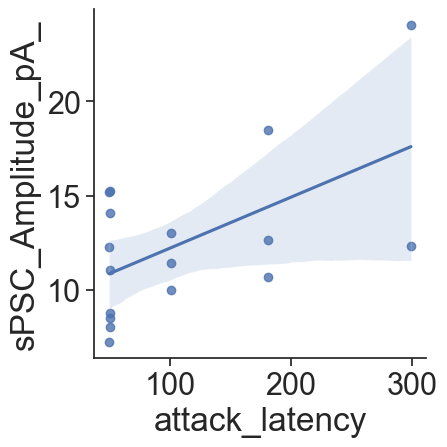

In [20]:
#ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != 'contact_latency':  # Skip the contact_latency column
        formula = 'attack_latency ~ ' + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_latency', y = y, data = ephys_behav)
                plt.show()
           
        except Exception as e:
            continue
    

In [9]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100',
       'agrp_100_paired', 'agrp_100', 'ZD7288', 'ZD7288_20', 'npykd'],
      dtype=object)

## all properties

Cm(pF) ('Pre', 'Agg+') 0.2112995473337107
Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.010819464803954192
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.050500440681557957
Firing_freq_(Hz)_I0 ('Pre', 'npy1r_antag') 0.2573383694997692
Firing_freq_(Hz)_I0 ('Pre', 'npy2r_antag') 0.9719814151577115
Firing_freq_(Hz)_I0 ('Pre', 'npy_10') 0.7522137312931874
Firing_freq_(Hz)_I0 ('Pre', 'npy_100') 0.012211708544648665
Firing_freq_(Hz)_I0 ('Pre', 'ZD7288') 0.00160254915119926
Firing_freq_(Hz)_I0 ('Pre', 'npykd') 0.9639435271433152
Firing_freq_(Hz)_I0 ('Agg+', 'Agg-') 0.000409831745363416
Firing_freq_(Hz)_I0 ('Agg+', 'npy1r_antag') 0.01378110226214151
Firing_freq_(Hz)_I0 ('Agg+', 'npy2r_antag') 0.11879034695155981
Firing_freq_(Hz)_I0 ('Agg+', 'npy_10') 0.023627602742951646
Firing_freq_(Hz)_I0 ('Agg+', 'npy_100') 0.10452265798969275
Firing_freq_(Hz)_I0 ('Agg+', 'ZD7288') 0.08873673305386351
Firing_freq_(Hz)_I0 ('Agg+', 'npykd') 0.24115314691780754
Firing_freq_(Hz)_I0 ('Agg-', 'npy1r_antag') 0.7211105212310518
Fir

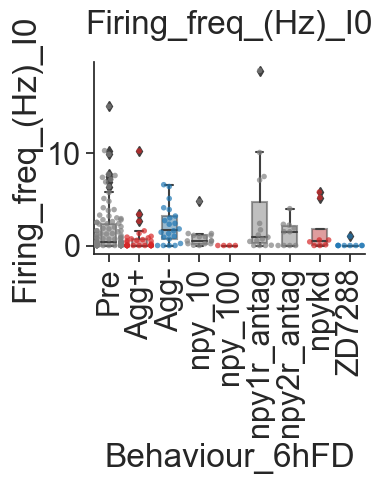

Instant_freq_(Hz) ('Pre', 'Agg+') 0.007126302284415039
Instant_freq_(Hz) ('Pre', 'Agg-') 0.13791987695468466
Instant_freq_(Hz) ('Pre', 'npy1r_antag') 0.3387879475549421
Instant_freq_(Hz) ('Pre', 'npy2r_antag') 1.0
Instant_freq_(Hz) ('Pre', 'npy_10') 0.8074135310571166
Instant_freq_(Hz) ('Pre', 'npy_100') 0.012216441132693882
Instant_freq_(Hz) ('Pre', 'ZD7288') 0.002066214299640664
Instant_freq_(Hz) ('Pre', 'npykd') 0.9684493380361244
Instant_freq_(Hz) ('Agg+', 'Agg-') 0.0010172795558072499
Instant_freq_(Hz) ('Agg+', 'npy1r_antag') 0.011311535506048284
Instant_freq_(Hz) ('Agg+', 'npy2r_antag') 0.142267991566083
Instant_freq_(Hz) ('Agg+', 'npy_10') 0.02033905481943857
Instant_freq_(Hz) ('Agg+', 'npy_100') 0.10441857452825822
Instant_freq_(Hz) ('Agg+', 'ZD7288') 0.09900021305885116
Instant_freq_(Hz) ('Agg+', 'npykd') 0.22695910926067964
Instant_freq_(Hz) ('Agg-', 'npy1r_antag') 0.9381289063266207
Instant_freq_(Hz) ('Agg-', 'npy2r_antag') 0.4989722884992587
Instant_freq_(Hz) ('Agg-', 'npy_

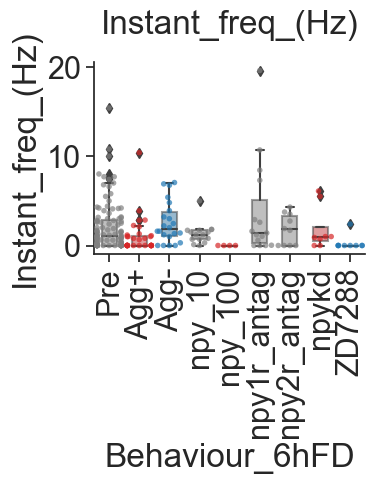

isi_(ms) ('Pre', 'Agg+') 0.8015286410640747
isi_(ms) ('Pre', 'Agg-') 0.054024744647440136
isi_(ms) ('Pre', 'npy1r_antag') 0.292912278038327
isi_(ms) ('Pre', 'npy2r_antag') 0.22888241165487228
isi_(ms) ('Pre', 'npy_10') 0.19083431548398933
CaT ('Pre', 'Agg+') 0.49563408102644235
CaT ('Pre', 'Agg-') 0.3954543611558381
CaT ('Pre', 'npy1r_antag') 0.5461647859931317
CaT ('Pre', 'npy2r_antag') 0.2874387902140235
CaT ('Pre', 'npy_10') 0.04651313339583601
CaT ('Pre', 'npy_100') 0.1481653894228193
CaT ('Pre', 'ZD7288') 0.726065942091648
CaT ('Pre', 'npykd') 0.4082970629907773
CaT ('Agg+', 'Agg-') 0.1718067166849695
CaT ('Agg+', 'npy1r_antag') 0.9086094786774864
CaT ('Agg+', 'npy2r_antag') 0.5920321732352896
CaT ('Agg+', 'npy_10') 0.18520400662349512
CaT ('Agg+', 'npy_100') 0.22825867911282194
CaT ('Agg+', 'ZD7288') 0.8865276989284464
CaT ('Agg+', 'npykd') 0.6387927824795692
CaT ('Agg-', 'npy1r_antag') 0.16745288464179808
CaT ('Agg-', 'npy2r_antag') 0.14511150176318646
CaT ('Agg-', 'npy_10') 0.0

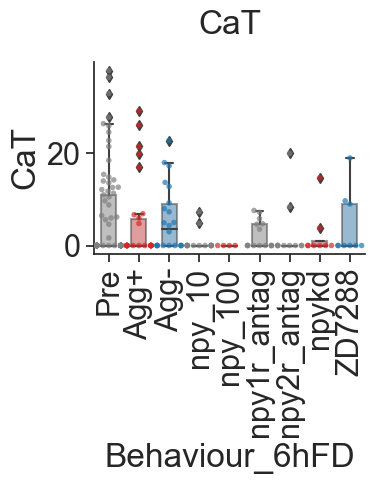

Ih_at_-120mV ('Pre', 'Agg+') 0.016953540388972527
Ih_at_-120mV ('Pre', 'Agg-') 0.5161858338475181
Ih_at_-120mV ('Pre', 'npy1r_antag') 0.895539682433509
Ih_at_-120mV ('Pre', 'npy2r_antag') 0.3510377171721971
Ih_at_-120mV ('Pre', 'npy_10') 0.04298660120520486
Ih_at_-120mV ('Pre', 'npy_100') 0.015932331746418678
Ih_at_-120mV ('Pre', 'ZD7288') 0.00038696578446780085
Ih_at_-120mV ('Pre', 'npykd') 0.5005470200340139
Ih_at_-120mV ('Agg+', 'Agg-') 0.0012473463277721786
Ih_at_-120mV ('Agg+', 'npy1r_antag') 0.14420227060743224
Ih_at_-120mV ('Agg+', 'npy2r_antag') 0.2714397846596408
Ih_at_-120mV ('Agg+', 'npy_10') 0.7891993382904234
Ih_at_-120mV ('Agg+', 'npy_100') 0.04094808268741189
Ih_at_-120mV ('Agg+', 'ZD7288') 0.0029161894382185396
Ih_at_-120mV ('Agg+', 'npykd') 0.4895229383027747
Ih_at_-120mV ('Agg-', 'npy1r_antag') 0.5054880344356945
Ih_at_-120mV ('Agg-', 'npy2r_antag') 0.08384103447372047
Ih_at_-120mV ('Agg-', 'npy_10') 0.009854341957769078
Ih_at_-120mV ('Agg-', 'npy_100') 0.003082271414

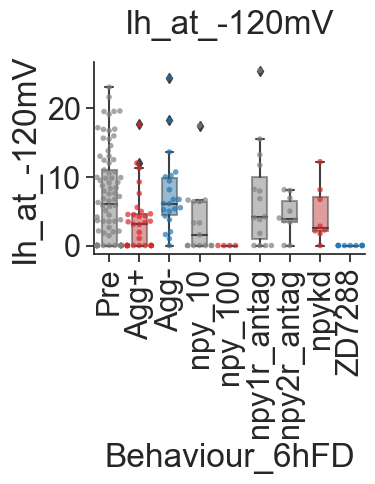

AP_ampl ('Pre', 'Agg+') 0.3025141906911134
AP_ampl ('Pre', 'Agg-') 0.6484995979902848
AP_ampl ('Pre', 'npy1r_antag') 0.0019617391708031686
AP_ampl ('Pre', 'npy2r_antag') 0.16993115240275336
AP_ampl ('Pre', 'npy_10') 0.004388294648604545
AP_halfwidth ('Pre', 'Agg+') 0.46219593535882597
AP_halfwidth ('Pre', 'Agg-') 0.04959538934130666
AP_halfwidth ('Pre', 'npy1r_antag') 0.8858255259367204
AP_halfwidth ('Pre', 'npy2r_antag') 0.8846865050190295
AP_halfwidth ('Pre', 'npy_10') 0.4113404558415319
AP_time_to_peak ('Pre', 'Agg+') 0.43721735287798613
AP_time_to_peak ('Pre', 'Agg-') 0.8469049089292453
AP_time_to_peak ('Pre', 'npy1r_antag') 0.03377040596934124
AP_time_to_peak ('Pre', 'npy2r_antag') 0.344590387533354
AP_time_to_peak ('Pre', 'npy_10') 0.2762024722179164
area(mV_ms) ('Pre', 'Agg+') 0.7991136298069239
area(mV_ms) ('Pre', 'Agg-') 0.016837642364698622
area(mV_ms) ('Pre', 'npy1r_antag') 0.2426447163920502
area(mV_ms) ('Pre', 'npy2r_antag') 0.30722417858225015
area(mV_ms) ('Pre', 'npy_10'

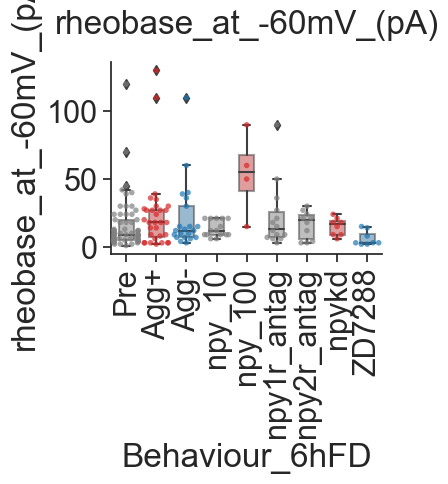

AHP_(mV) ('Pre', 'Agg+') 0.43839162689464706
AHP_(mV) ('Pre', 'Agg-') 0.682407498428275
AHP_(mV) ('Pre', 'npy1r_antag') 0.1042686796936504
AHP_(mV) ('Pre', 'npy2r_antag') 0.4415405624351012
AHP_(mV) ('Pre', 'npy_10') 0.9339974866580283
Vm ('Pre', 'Agg+') 0.7001860857748857
Vm ('Pre', 'Agg-') 0.5059726708502595
Vm ('Pre', 'npy1r_antag') 0.06155381242762307
Vm ('Pre', 'npy2r_antag') 0.8687269926970953
Vm ('Pre', 'npy_10') 0.44928219290153704
Vm ('Pre', 'npy_100') 0.15524412237513982
Vm ('Pre', 'ZD7288') 0.05696856621362753
Vm ('Pre', 'npykd') 0.00025408044737030606
Vm ('Agg+', 'Agg-') 0.911084019139028
Vm ('Agg+', 'npy1r_antag') 0.26607738079943555
Vm ('Agg+', 'npy2r_antag') 0.9198537663906738
Vm ('Agg+', 'npy_10') 0.7895075436379628
Vm ('Agg+', 'npy_100') 0.1859641153758801
Vm ('Agg+', 'ZD7288') 0.16777100640194242
Vm ('Agg+', 'npykd') 0.0049384475873942004
Vm ('Agg-', 'npy1r_antag') 0.15927452165285128
Vm ('Agg-', 'npy2r_antag') 0.8230632737581215
Vm ('Agg-', 'npy_10') 0.81647830932886

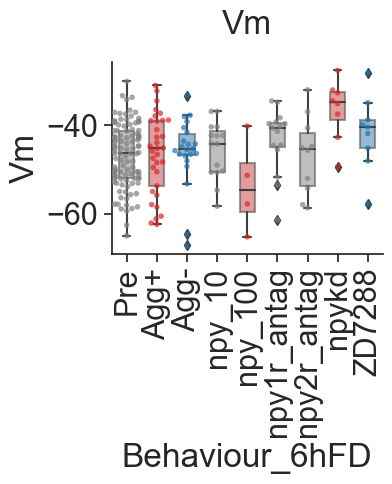

Input_Resistance ('Pre', 'Agg+') 0.00959484260193699
Input_Resistance ('Pre', 'Agg-') 0.7897476721570257
Input_Resistance ('Pre', 'npy1r_antag') 0.20332306298223934
Input_Resistance ('Pre', 'npy2r_antag') 0.3971444938340719
Input_Resistance ('Pre', 'npy_10') 0.0018205584225745807
Input_Resistance ('Pre', 'npy_100') 0.2754541323394027
Input_Resistance ('Pre', 'ZD7288') 0.0012071520714673186
Input_Resistance ('Pre', 'npykd') 0.0005961767803981232
Input_Resistance ('Agg+', 'Agg-') 0.04608250364957072
Input_Resistance ('Agg+', 'npy1r_antag') 0.4121413951366578
Input_Resistance ('Agg+', 'npy2r_antag') 0.5139400328000707
Input_Resistance ('Agg+', 'npy_10') 0.3249635822878799
Input_Resistance ('Agg+', 'npy_100') 0.9402597402597401
Input_Resistance ('Agg+', 'ZD7288') 0.10535123506497364
Input_Resistance ('Agg+', 'npykd') 0.09918732519351714
Input_Resistance ('Agg-', 'npy1r_antag') 0.24603234909826666
Input_Resistance ('Agg-', 'npy2r_antag') 0.4279015021061038
Input_Resistance ('Agg-', 'npy_10'

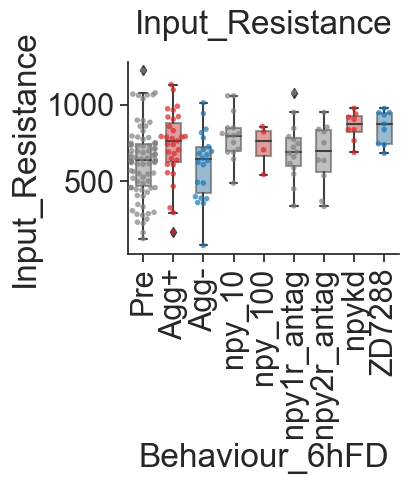

sPSC_frequency ('Pre', 'Agg+') 0.6299516553223251
sPSC_frequency ('Pre', 'Agg-') 0.16569340327720272
sPSC_frequency ('Pre', 'npy1r_antag') 0.007897739636139703
sPSC_frequency ('Pre', 'npy2r_antag') 0.03902562359917241
sPSC_frequency ('Pre', 'npy_10') 0.0860132039524211
sPSC_frequency ('Pre', 'npy_100') 0.4718240507714192
sPSC_frequency ('Pre', 'ZD7288') 0.00012029387794381674
sPSC_frequency ('Pre', 'npykd') 0.18942796576614532
sPSC_frequency ('Agg+', 'Agg-') 0.4758363925692679
sPSC_frequency ('Agg+', 'npy1r_antag') 0.004334839305559387
sPSC_frequency ('Agg+', 'npy2r_antag') 0.03447280362946219
sPSC_frequency ('Agg+', 'npy_10') 0.07085963754292053
sPSC_frequency ('Agg+', 'npy_100') 0.6513456039213052
sPSC_frequency ('Agg+', 'ZD7288') 0.0014364535876886526
sPSC_frequency ('Agg+', 'npykd') 0.2057709819012573
sPSC_frequency ('Agg-', 'npy1r_antag') 0.0015203172563771129
sPSC_frequency ('Agg-', 'npy2r_antag') 0.007745807515973355
sPSC_frequency ('Agg-', 'npy_10') 0.024980650054050743
sPSC_fr

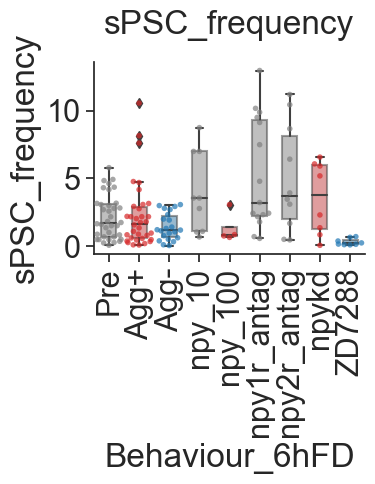

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.5687163130626809
sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.025875307502539382
sPSC_Amplitude(pA) ('Pre', 'npy1r_antag') 0.5216038164206143
sPSC_Amplitude(pA) ('Pre', 'npy2r_antag') 0.3651920681833466
sPSC_Amplitude(pA) ('Pre', 'npy_10') 0.8314555344756641
sPSC_Amplitude(pA) ('Pre', 'npy_100') 0.1690971297669901
sPSC_Amplitude(pA) ('Pre', 'ZD7288') 0.002009908114278183
sPSC_Amplitude(pA) ('Pre', 'npykd') 0.7959007659035642
sPSC_Amplitude(pA) ('Agg+', 'Agg-') 0.059016462042317176
sPSC_Amplitude(pA) ('Agg+', 'npy1r_antag') 0.7203917662706332
sPSC_Amplitude(pA) ('Agg+', 'npy2r_antag') 0.2809375228491704
sPSC_Amplitude(pA) ('Agg+', 'npy_10') 0.8931110395377335
sPSC_Amplitude(pA) ('Agg+', 'npy_100') 0.16775148995448252
sPSC_Amplitude(pA) ('Agg+', 'ZD7288') 0.003379108413355577
sPSC_Amplitude(pA) ('Agg+', 'npykd') 0.6308818081479559
sPSC_Amplitude(pA) ('Agg-', 'npy1r_antag') 0.7451488435418439
sPSC_Amplitude(pA) ('Agg-', 'npy2r_antag') 0.039842458649280016
sPSC

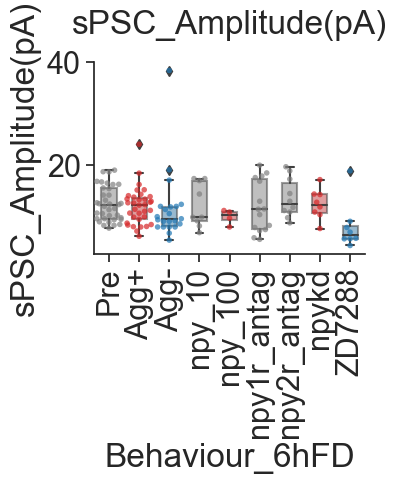

sPSCs_Rise time ('Pre', 'Agg+') 0.5523105533089088
sPSCs_Rise time ('Pre', 'Agg-') 0.3970241676687203
sPSCs_Rise time ('Pre', 'npy1r_antag') 0.9820976399517795
sPSCs_Rise time ('Pre', 'npy2r_antag') 0.9768442965316141
sPSCs_Rise time ('Pre', 'npy_10') 0.6762317557648871
sPSCs_Rise time ('Pre', 'npy_100') 0.10353772201579133
sPSCs_Rise time ('Pre', 'ZD7288') 0.5400376799085684
sPSCs_Rise time ('Pre', 'npykd') 0.3453524979983694
sPSCs_Rise time ('Agg+', 'Agg-') 0.24122416689162263
sPSCs_Rise time ('Agg+', 'npy1r_antag') 0.7596540919314303
sPSCs_Rise time ('Agg+', 'npy2r_antag') 0.7995867474237126
sPSCs_Rise time ('Agg+', 'npy_10') 1.0
sPSCs_Rise time ('Agg+', 'npy_100') 0.19608906475251975
sPSCs_Rise time ('Agg+', 'ZD7288') 0.7597296065659777
sPSCs_Rise time ('Agg+', 'npykd') 0.2806844744882403
sPSCs_Rise time ('Agg-', 'npy1r_antag') 0.29648351958617036
sPSCs_Rise time ('Agg-', 'npy2r_antag') 0.48532355595130283
sPSCs_Rise time ('Agg-', 'npy_10') 0.45717191551165437
sPSCs_Rise time ('Agg

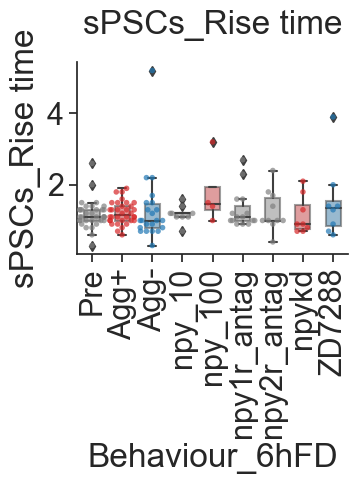

sPSCs (decay) ('Pre', 'Agg+') 0.445197370104469
sPSCs (decay) ('Pre', 'Agg-') 0.5852881642217079
sPSCs (decay) ('Pre', 'npy1r_antag') 0.18937115235964863
sPSCs (decay) ('Pre', 'npy2r_antag') 0.29435613580791864
sPSCs (decay) ('Pre', 'npy_10') 0.08583563248185513
sPSCs (decay) ('Pre', 'npy_100') 0.39277248879536075
sPSCs (decay) ('Pre', 'ZD7288') 0.33514868886616145
sPSCs (decay) ('Pre', 'npykd') 0.34365140176047293
sPSCs (decay) ('Agg+', 'Agg-') 0.9861774126895494
sPSCs (decay) ('Agg+', 'npy1r_antag') 0.43482039170687026
sPSCs (decay) ('Agg+', 'npy2r_antag') 0.6240645324651697
sPSCs (decay) ('Agg+', 'npy_10') 0.3171835069285409
sPSCs (decay) ('Agg+', 'npy_100') 0.5420849420849421
sPSCs (decay) ('Agg+', 'ZD7288') 0.3042033696719191
sPSCs (decay) ('Agg+', 'npykd') 0.6082736653406708
sPSCs (decay) ('Agg-', 'npy1r_antag') 0.2752236364320767
sPSCs (decay) ('Agg-', 'npy2r_antag') 0.4594162960144851
sPSCs (decay) ('Agg-', 'npy_10') 0.17422681833334774
sPSCs (decay) ('Agg-', 'npy_100') 0.79334

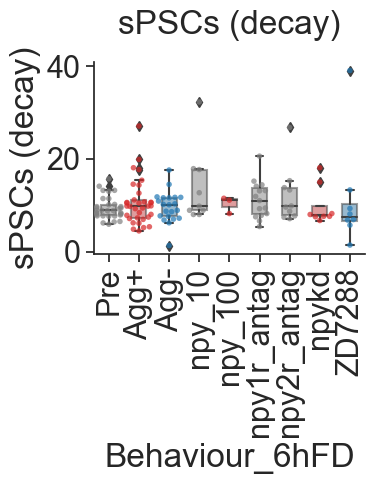

In [13]:
filter_cat = ['Pre', 'Agg+', 'Agg-', 'npy_10', 'npy_100', 'npy1r_antag', 'npy2r_antag', 'npykd', 'ZD7288']


preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan', 
                palette=['Gray', 'Tab:red', 'Tab:Blue', 'Gray', 'Tab:red', 'Gray'], order = filter_cat,
                  plotting= True)


Cm(pF) ('yes', 'no') 0.7301587301587302
Gal_positive
no     48.160853
yes    43.144010
Name: Cm(pF), dtype: float64


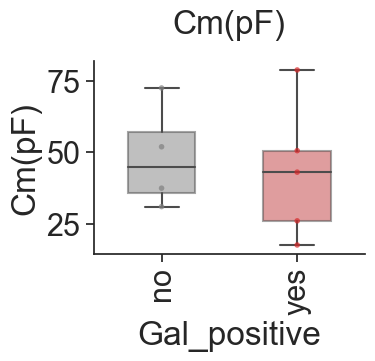

Firing_freq_(Hz)_I0 ('yes', 'no') 1.0
Gal_positive
no     2.565
yes    0.740
Name: Firing_freq_(Hz)_I0, dtype: float64


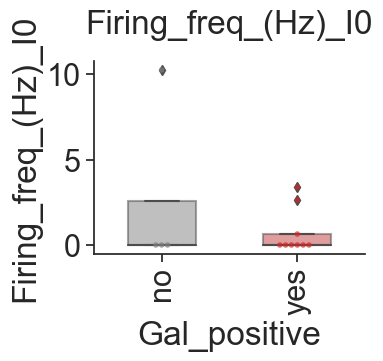

Instant_freq_(Hz) ('yes', 'no') 1.0
Gal_positive
no     2.600000
yes    0.871111
Name: Instant_freq_(Hz), dtype: float64


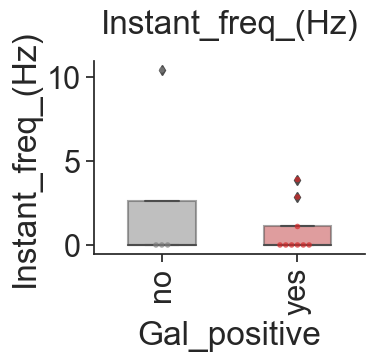

isi_(ms) ('yes', 'no') 0.5
Gal_positive
no      97.420000
yes    740.333333
Name: isi_(ms), dtype: float64


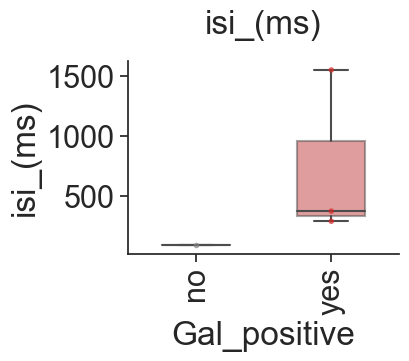

CaT ('yes', 'no') 0.5842375964997912
Gal_positive
no     8.507500
yes    1.842857
Name: CaT, dtype: float64


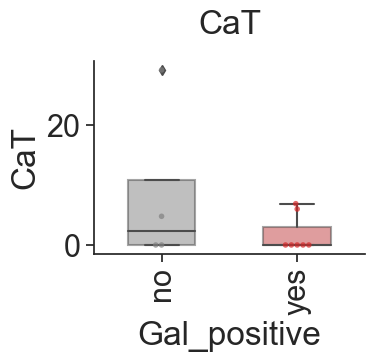

Ih_at_-120mV ('yes', 'no') 0.5376384478605154
Gal_positive
no     3.28750
yes    4.52875
Name: Ih_at_-120mV, dtype: float64


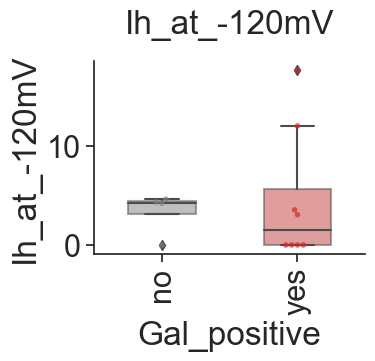

AP_ampl ('yes', 'no') 0.5
Gal_positive
no     98.400000
yes    70.266667
Name: AP_ampl, dtype: float64


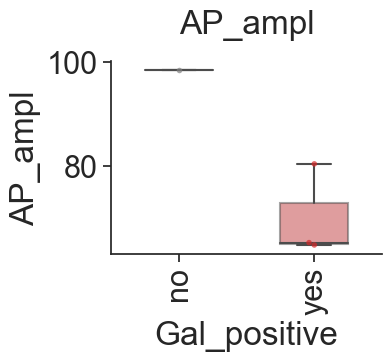

AP_halfwidth ('yes', 'no') 0.5
Gal_positive
no     1.710000
yes    3.613333
Name: AP_halfwidth, dtype: float64


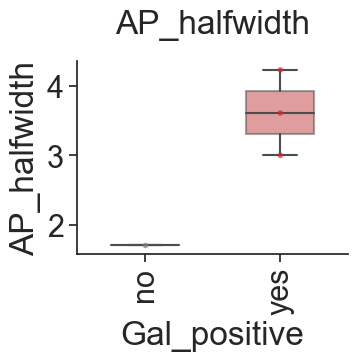

AP_time_to_peak ('yes', 'no') 0.5
Gal_positive
no     0.620000
yes    2.026667
Name: AP_time_to_peak, dtype: float64


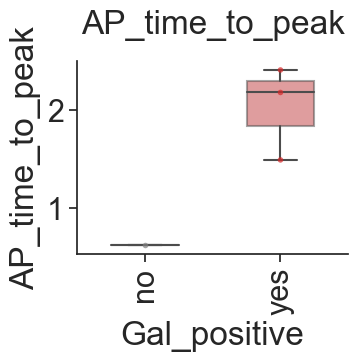

area(mV_ms) ('yes', 'no') 0.5
Gal_positive
no     132.000000
yes    240.766667
Name: area(mV_ms), dtype: float64


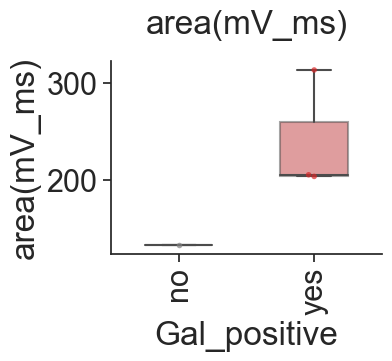

rheobase_at_-60mV_(pA) ('yes', 'no') 0.9309874465595671
Gal_positive
no     39.5
yes    20.5
Name: rheobase_at_-60mV_(pA), dtype: float64


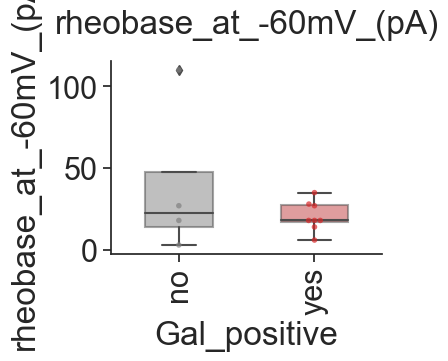

AHP_(mV) ('yes', 'no') 0.5
Gal_positive
no    -53.700000
yes   -44.816667
Name: AHP_(mV), dtype: float64


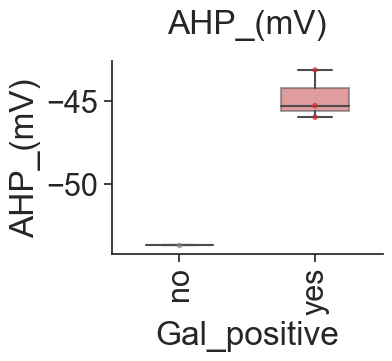

Vm ('yes', 'no') 0.005594405594405594
Gal_positive
no    -54.158175
yes   -39.845540
Name: Vm, dtype: float64


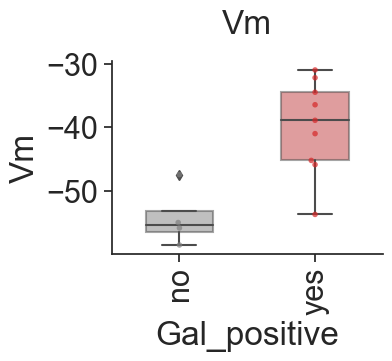

Input_Resistance ('yes', 'no') 0.6828282828282828
Gal_positive
no     672.011750
yes    680.159409
Name: Input_Resistance, dtype: float64


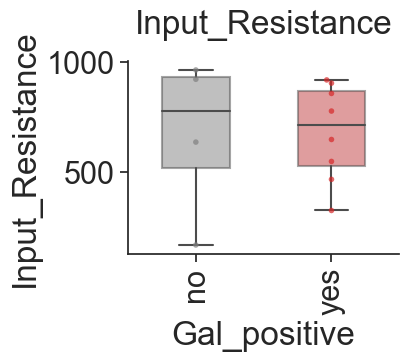

sPSC_frequency ('yes', 'no') 0.6041958041958042
Gal_positive
no     1.634487
yes    2.964686
Name: sPSC_frequency, dtype: float64


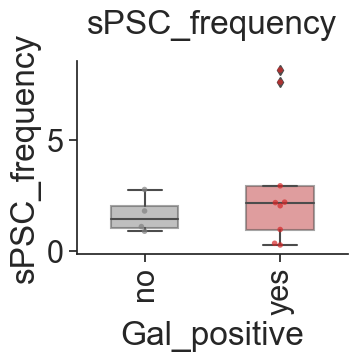

sPSC_Amplitude(pA) ('yes', 'no') 0.5034965034965035
Gal_positive
no     11.982500
yes    10.981111
Name: sPSC_Amplitude(pA), dtype: float64


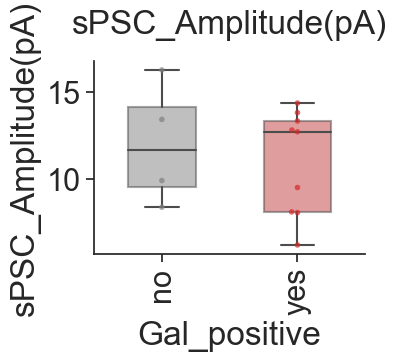

sPSCs_Rise time ('yes', 'no') 0.8139237277305011
Gal_positive
no     1.275000
yes    1.188889
Name: sPSCs_Rise time, dtype: float64


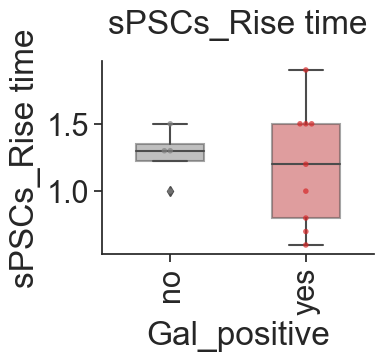

sPSCs (decay) ('yes', 'no') 0.1986013986013986
Gal_positive
no      8.942500
yes    12.294444
Name: sPSCs (decay), dtype: float64


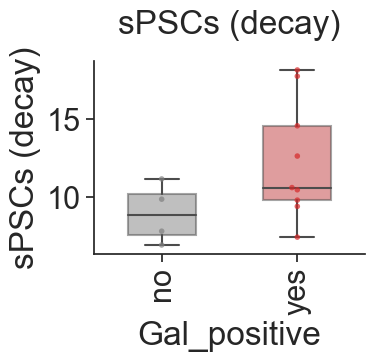

In [11]:
preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))], 
                'Gal_positive', 'gal', palette=['Gray', 'Tab:red'], order = ['no', 'yes'], plotting= True)


Cm(pF) nan
Firing_freq_(Hz)_I0 nan
Instant_freq_(Hz) nan
isi_(ms) nan
CaT nan
Ih_at_-120mV nan
AP_ampl nan
AP_halfwidth nan
AP_time_to_peak nan
area(mV_ms) nan
rheobase_at_-60mV_(pA) nan
AHP_(mV) nan
Vm nan
Input_Resistance nan
sPSC_frequency nan
sPSC_Amplitude(pA) nan
sPSCs_Rise time nan
sPSCs (decay) nan
AC-I0 nan
AC_-60 nan


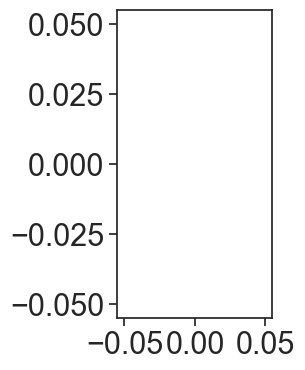

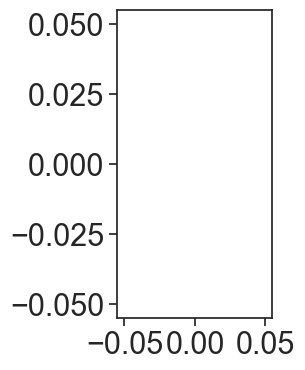

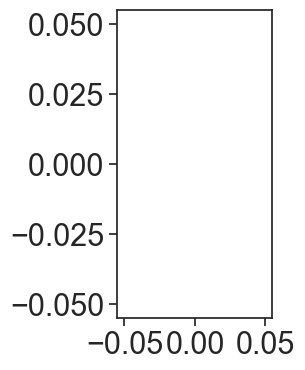

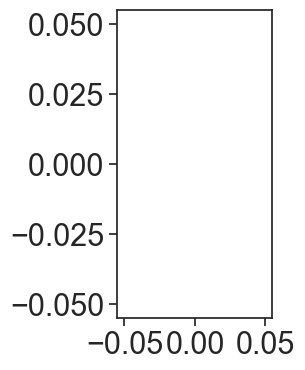

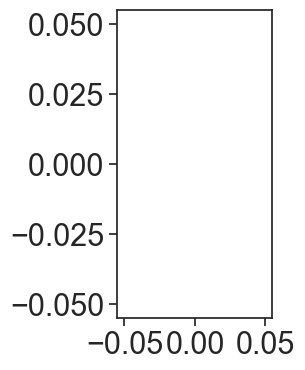

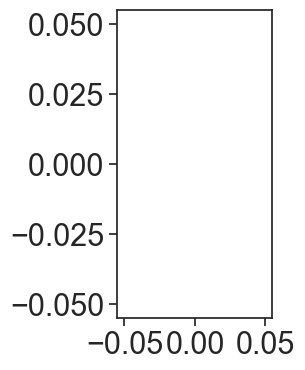

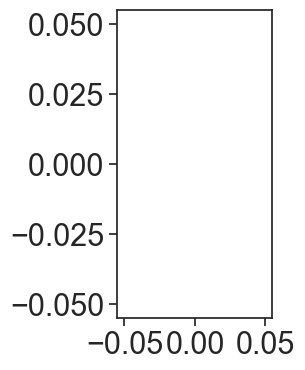

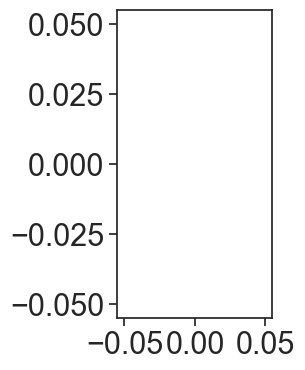

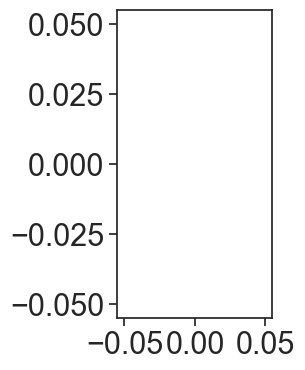

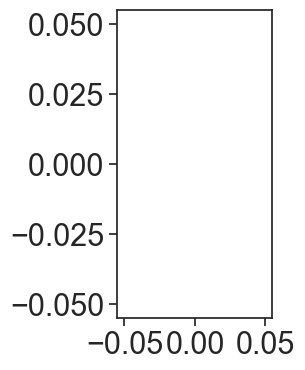

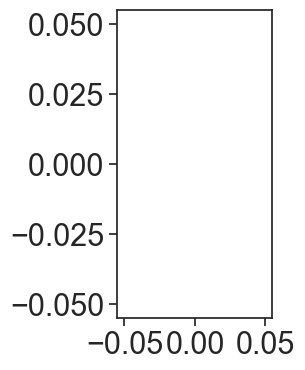

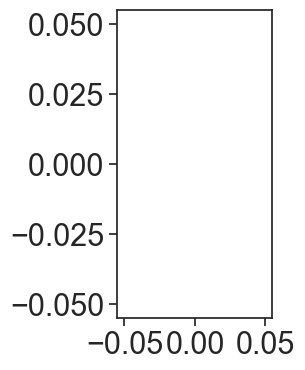

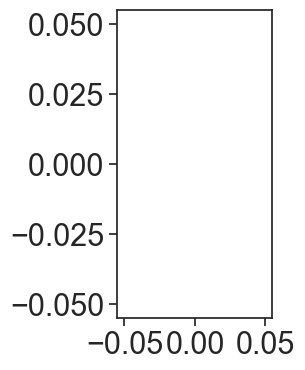

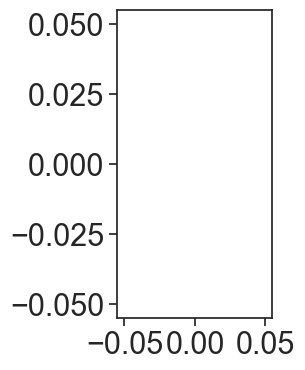

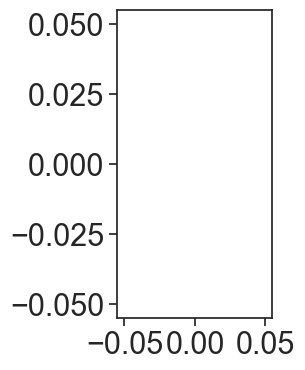

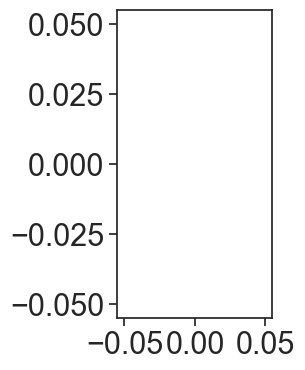

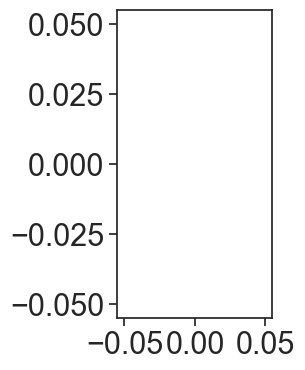

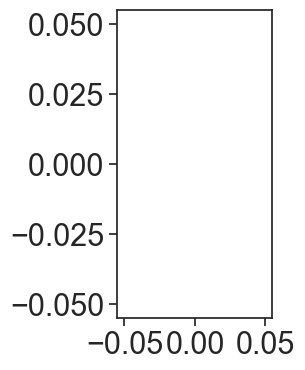

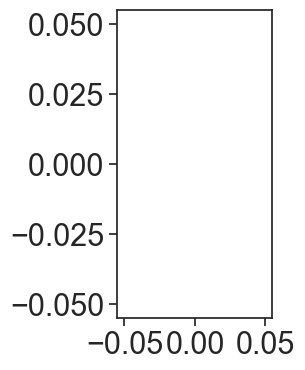

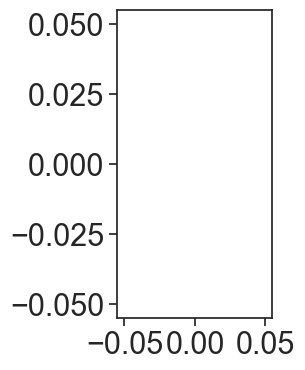

In [15]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.Behaviour_6hFD.isin(['Agg+', 'Agg-'])]

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    try:
        _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                    gals[(gals.Gal_positive == 'no')][column].dropna(),
                                    equal_var = False)
        print(column , p)


        gals[column] = pd.to_numeric(gals[column])
        fig,ax = plt.subplots(figsize = (2,4))
        sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
        sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
        sns.despine()
        plt.title(column + '_' + str(p)[:3])
        plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
        plt.show()
    except Exception:
        continue

In [16]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('Input_Resistance ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,4.622169e+05,1.0,9.561557,0.002425
Residual,6.381035e+06,132.0,NaN,NaN


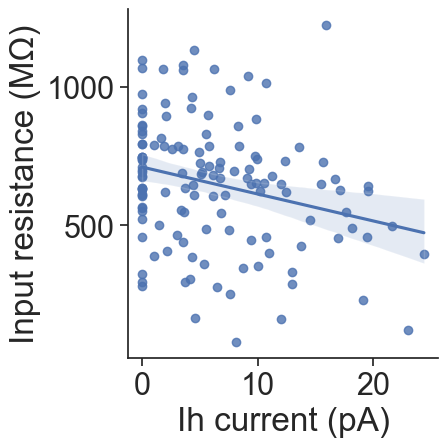

In [17]:
sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'])
plt.xlabel('Ih current (pA)')
plt.ylabel('Input resistance (MΩ)')
plt.savefig(f'output_figures/ih_input_resistance.png',dpi = 300, bbox_inches = 'tight')
          


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


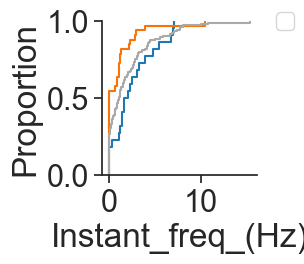

In [18]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

## silent prop

I_zero          phasic  phasic   silent  tonic  All
Behaviour_6hFD                                     
Agg+                 7        0      18      8   33
Agg-                 4        0       4     14   22
Pre                 19        0      28     58  105
npy1r_antag          2        0       3     10   15
npy_10               2        0       1     12   15
npykd                0        1       2      5    8
All                 34        1      56    107  198
5.6900600395315774e-05


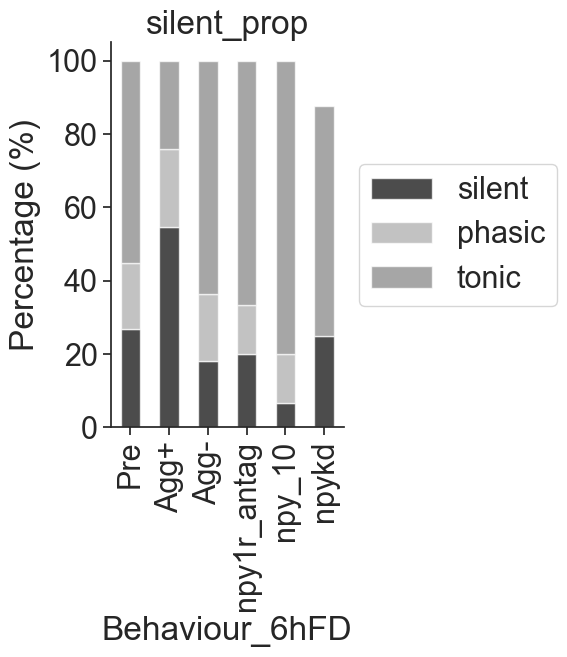

In [11]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'npy1r_antag', 'npy_10', 'npykd']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [28]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## adaptive prop

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Pre             1  15   27   43
Agg+            1  12   16   29
Agg-            0  18    3   21
All             2  45   46   93
0.0035491449670240205


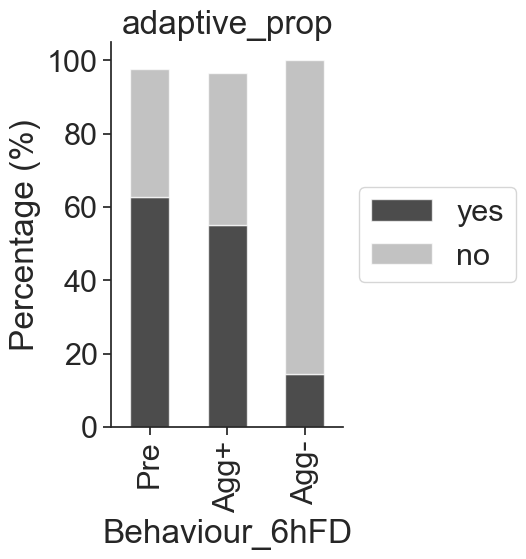

In [29]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])

prop_plot(ad_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

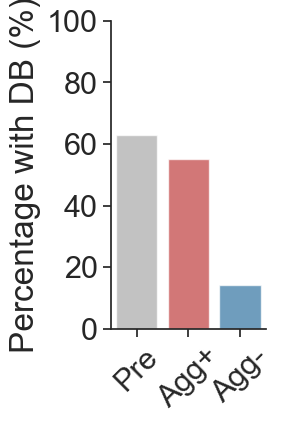

In [38]:
plt.subplots(figsize = (2,4))
sns.barplot(x = 'Behaviour_6hFD', y = 'yes',data = ad_prop, palette= ['darkgray', 'Tab:red', 'Tab:blue'], alpha = 0.7)
plt.xticks(rotation = 45)
plt.ylim([0,100])
plt.ylabel('Percentage with DB (%)')
plt.xlabel('')
sns.despine()
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

In [77]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## calcium T prop

cat_categ         no  no   yes  yes   All
Behaviour_6hFD                           
Agg+              20    0    8     0   28
Agg-               9    1   11     1   22
Pre               51    0   31     0   82
ZD7288             6    0    3     0    9
ZD7288_20          2    0    1     0    3
agrp_100           7    0    0     0    7
agrp_100_paired    6    0    1     0    7
npy_10             3    1    0     0    4
npy_100            4    0    0     0    4
npy_antag         14    0    1     0   15
All              122    2   56     1  181
0.004202880379034892


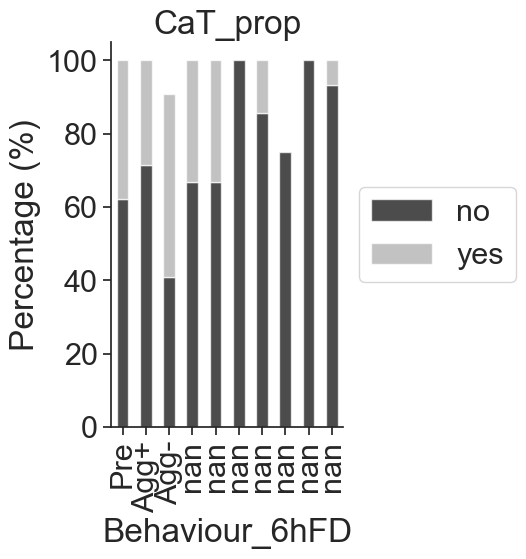

In [114]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

In [79]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## IH prop

IH               no  yes  All
Behaviour_6hFD               
Agg+             11   17   28
Agg-              1   21   22
Pre              24   58   82
ZD7288            9    0    9
ZD7288_20         3    0    3
agrp_100          5    2    7
agrp_100_paired   1    6    7
npy_10            3    1    4
npy_100           4    0    4
npy_100_paired    2    1    3
npy_10_paired     0    5    5
npy_antag         3   12   15
All              66  123  189
1.2495740282987222e-07


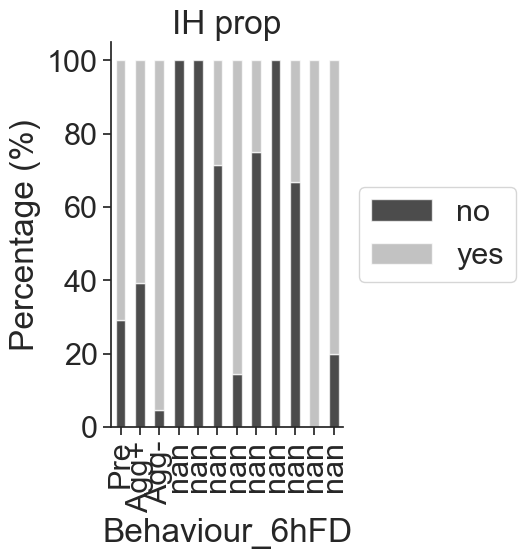

In [116]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                7   25   32
silent               31   39   70
tonic                26   59   85
All                  64  123  187
0.05461411697391892


Text(0.5, 0, '')

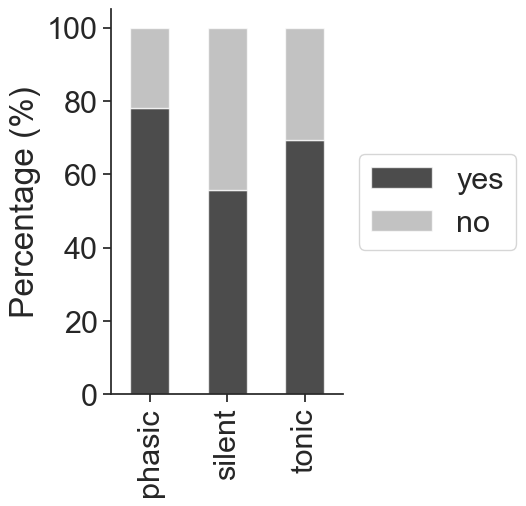

In [117]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# ramp analysis

In [ ]:
df = pd.read_csv('ramps_all.csv')
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)', 
                        'experiment_day':'filename'}, inplace =True)

df.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
df = pd.merge(df, ephys, on = 'filename')

df['Injected'] = pd.Categorical(df['Injected'], df['Injected'].unique()[:-2]).as_ordered()

start = df['Ramp_start'][0]
num_spike = df.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')
df = df.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

df.loc[df['Event start '] == 0,'Event start '] = 2080
df['latency'] = df['Event start ']- start
df['num_spike'] = num_spike.num_spike
df =  pd.merge(df, ephys, on = ['filename', 'Behaviour_6hFD'])



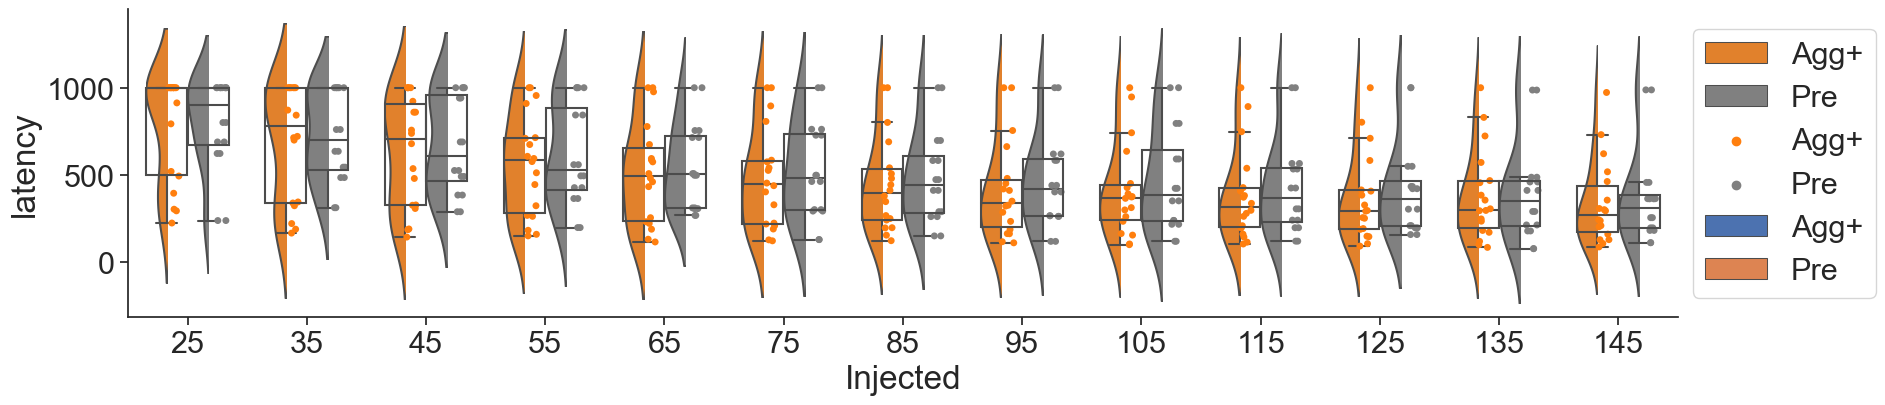

In [ ]:
prop = 'latency'

fig = plt.subplots(figsize = [20,4])

palette = ['Tab:orange', 'gray']
ax = sns.violinplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', 
                    dodge = True, data = df,
                    palette=palette,width = 0.7,
                    scale="width", inner=None)

# ax = sns.lmplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', data = df)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

old_len_collections = len(ax.collections)
sns.stripplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
               dodge = True, data = df, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
                data = df, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)


for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([.08, 0]))
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)

sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [ ]:
model = smf.ols('latency ~ C(Injected) * C(Behaviour_6hFD)', data=df).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),7.381683e+06,12.0,8.054835,1.237526e-13
C(Behaviour_6hFD),1.470714e+05,1.0,1.925798,1.659617e-01
C(Injected):C(Behaviour_6hFD),1.909296e+04,12.0,0.020834,1.000000e+00
Residual,3.176953e+07,416.0,NaN,NaN


In [ ]:
df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
m_comp._results_table

group1,group2,meandiff,p-adj,lower,upper,reject
105 / Agg+,105 / no_FD,53.6741,1.0,-402.1284,509.4766,False
105 / Agg+,115 / Agg+,-24.5592,1.0,-389.2012,340.0828,False
105 / Agg+,115 / no_FD,10.2366,1.0,-445.5659,466.0391,False
105 / Agg+,125 / Agg+,-40.0064,1.0,-404.6483,324.6356,False
105 / Agg+,125 / no_FD,-4.3258,1.0,-460.1283,451.4766,False
105 / Agg+,135 / Agg+,-25.7058,1.0,-390.3478,338.9361,False
105 / Agg+,135 / no_FD,-25.2135,1.0,-481.016,430.5889,False
105 / Agg+,145 / Agg+,-68.4944,1.0,-433.1364,296.1476,False
105 / Agg+,145 / no_FD,-48.6384,1.0,-504.4409,407.1641,False
105 / Agg+,25 / Agg+,359.0997,0.0598,-5.5423,723.7417,False


# estrous cycle influence

I_zero             phasic  silent  tonic  All
estrous_stage                                
?                       1       1      2    4
D                       5       7     16   28
E                       2       3      3    8
M                       3       7     14   24
P                       6       6     12   24
VS to be stained        0       0      1    1
no VS                   1       2      9   12
not taken               1       2      1    4
All                    19      28     58  105
0.9417552913501139
Empty DataFrame
Columns: []
Index: []


ValueError: No data; `observed` has size 0.

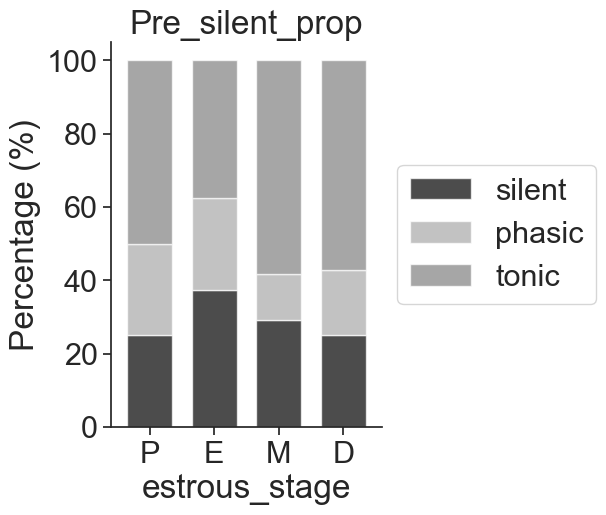

In [32]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
# ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

-0.5709724581245322 0.42902754187546777


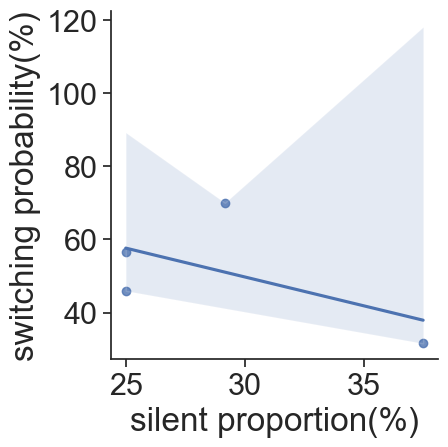

In [33]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

Ih_at_-120mV 0.009539512286860998


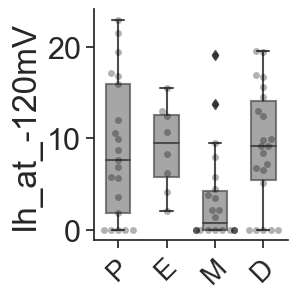

In [39]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

# ls = ['Ih_at_-120mV']

for state in ['Pre']:
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        state_df = state_df[state_df.Behaviour_6hFD == state]
        
        try:

            _, p = stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna())
            

            
            if p < 0.05:
                print(column , p)

                fig,ax = plt.subplots(figsize = (2.5,3))
                sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 0.3, color = 'black')
                sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5, palette = ['gray'])
                sns.despine()
                plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel('')
            
                # plt.title(f'{state}_{column}', pad = 20)
                plt.savefig(f'output_figures/{state}_{column}.png',dpi = 300, bbox_inches = 'tight')
            
            plt.show()
        except Exception:
            continue

cat_categ          no  yes  All
estrous_stage                  
?                   1    3    4
D                  11   11   22
E                   4    4    8
M                  17    5   22
P                  15    6   21
VS to be stained    1    0    1
not taken           2    2    4
All                51   31   82
0.23806780090893834
cat_categ estrous_stage         no        yes
4                     P  71.428571  28.571429
2                     E  50.000000  50.000000
3                     M  77.272727  22.727273
1                     D  50.000000  50.000000


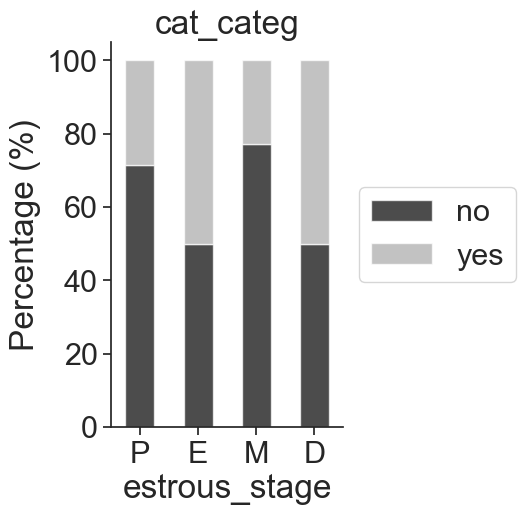

0.9146286513211039 0.08537134867889606


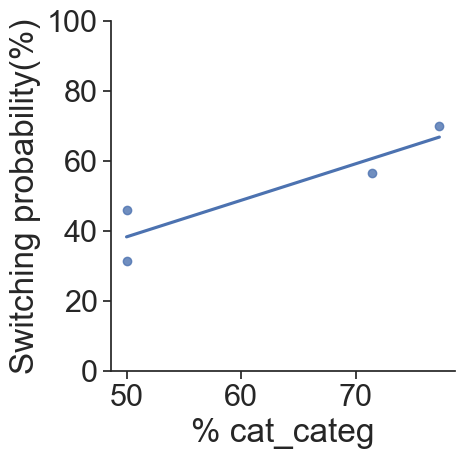

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   17   22
E                   0    8    8
M                  11   11   22
P                   5   16   21
VS to be stained    1    0    1
not taken           2    2    4
All                24   58   82
0.0352565677238345
IH estrous_stage         no         yes
4              P  23.809524   76.190476
2              E   0.000000  100.000000
3              M  50.000000   50.000000
1              D  22.727273   77.272727


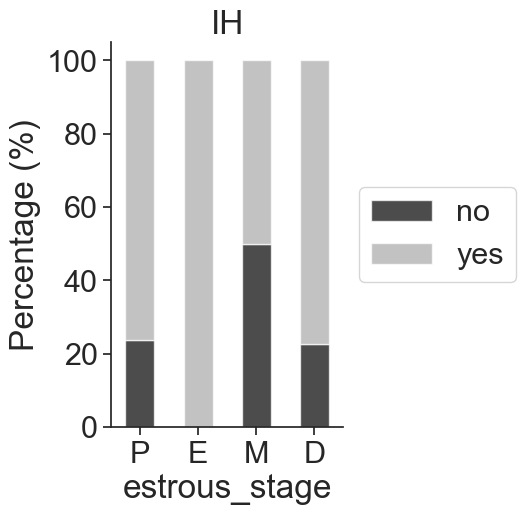

0.9665783850876507 0.033421614912349296


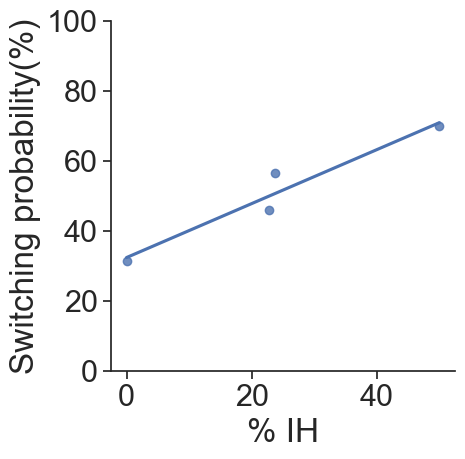

Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    6   10
E                  0   1    1    2
M                  0   7   11   18
P                  1   3    7   11
VS to be stained   0   0    1    1
All                1  15   27   43
0.9166519983189608
Adaptive estrous_stage         no        yes
4                    P  27.272727  63.636364
2                    E  50.000000  50.000000
3                    M  38.888889  61.111111
1                    D  40.000000  60.000000


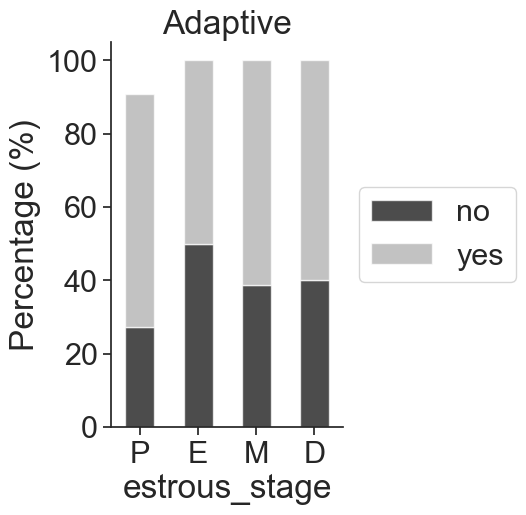

-0.6320737885969195 0.36792621140308046


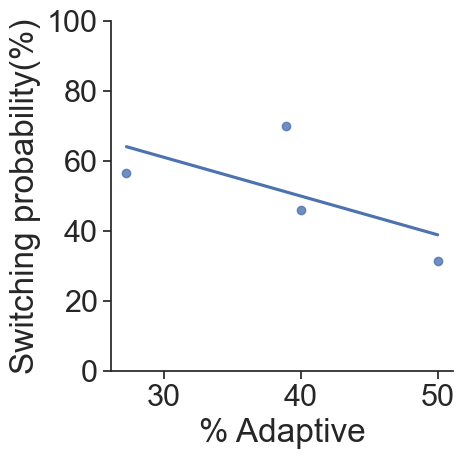

In [47]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr, ci = None)
    plt.ylim([0, 100])
    plt.xlabel(f'% {column}')
    plt.ylabel('Switching probability(%)')
    plt.savefig(f'output_figures/{column}_switching_corr.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   17   22
E                   0    8    8
M                  11   11   22
P                   5   16   21
VS to be stained    1    0    1
not taken           2    2    4
All                24   58   82
0.0352565677238345
Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    6   10
E                  0   1    1    2
M                  0   7   11   18
P                  1   3    7   11
VS to be stained   0   0    1    1
All                1  15   27   43
0.9166519983189608
-0.284545136651464 0.715454863348536


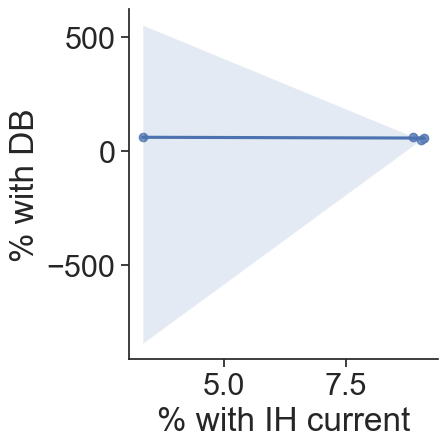

In [18]:

cols = ['no', 'yes']
estrous_stages = ['P', 'E', 'M', 'D']
ih_prop = proportion(ephys_pre, 'estrous_stage', 'IH', cols)
ih_est_mean = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
adaptive_prop = proportion(ephys_pre, 'estrous_stage', 'Adaptive', cols)
merged_df = pd.merge(ih_est_mean, adaptive_prop, on = 'estrous_stage')
merged_df = merged_df[merged_df.estrous_stage.isin(estrous_stages)]


r, p = sp.stats.pearsonr(merged_df['Ih_at_-120mV'], merged_df['yes'])
print(r, p)

sns.lmplot(x = 'Ih_at_-120mV', y = 'yes', data = merged_df)
# plt.ylim([0, /100])
plt.xlabel('% with IH current')
plt.ylabel('% with DB')
plt.show()